# 📦 UN Comtrade 무역 데이터 분석

> **실습 목표**
> 1. UN Comtrade에서 내려받은 무역 데이터를 불러오고 구조를 파악합니다.
> 2. 열 선택, 정렬, 필터링 등 기본 조작을 함수별로 연습합니다.
> 3. 결측치 처리와 파생변수 생성을 익힙니다.
> 4. 그룹 집계와 중복 처리, 시각화를 체험합니다.

---

### 📋 데이터 개요

| 컬럼명 | 설명 |
|:---|:---|
| **연도** | 신고 연도 (2020~2024) |
| **교역상대국** | 수출·수입 상대국 (China, USA, Viet Nam) |
| **수출입구분** | Export(수출) / Import(수입) |
| **HS코드** | 4자리 HS 품목 코드 |
| **품목명** | HS 코드에 해당하는 품목 설명 |
| **수량단위** | 수량의 단위 (u=개, kg 등) |
| **수량** | 수출·수입 수량 |
| **순중량(kg)** | 포장 제외 순 중량 |
| **CIF금액(\$)** | Cost+Insurance+Freight (수입 통관 기준) |
| **FOB금액(\$)** | Free on Board (수출 통관 기준) |
| **교역금액(\$)** | 실제 활용 교역 금액 (수출=FOB, 수입=CIF) |
| **HS분류버전** | HS 협약 버전 (H5 = 2022년 기준) |

---
## 0. 한글 폰트 설치 (Google Colab 사용 시)

그래프에서 한글이 깨지는 것을 방지합니다.  
아래 셀 실행 후 **런타임 → 세션 다시 시작** 을 눌러주세요.

In [ ]:
# Google Colab 환경에서만 실행
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,430 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

---
## 1. 라이브러리 불러오기

분석에 필요한 패키지를 가장 먼저 가져옵니다.

| 라이브러리 | 역할 |
|:---|:---|
| `pandas` | 표(DataFrame) 형태로 데이터를 다루는 핵심 도구 |
| `numpy` | 수치 계산·결측치(NaN) 처리 |
| `matplotlib` | 그래프 기본 설정 |
| `seaborn` | 통계 시각화 라이브러리 |

In [ ]:
import numpy as np




# 한글 폰트 및 마이너스 기호 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

라이브러리 불러오기 완료!


---
## 2. 데이터 불러오기 — `pd.read_excel()`

엑셀 파일을 pandas **DataFrame**으로 읽어옵니다.

In [ ]:
# 엑셀 파일 불러오기


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"12,293,389",12293389,H5
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"3,402,788",3402788,H5
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"166,872,635",166872635,H5
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0,"32,964",NaN,"1,313,112",1313112,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,NaN,27,NaN,27,H6
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,NaN,879,NaN,879,H6
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,NaN,"6,405",NaN,6405,H6


> 💡 **팁**: CSV 파일이라면 `pd.read_csv('파일명.csv', encoding='utf-8')` 를 사용합니다.

---
## 3. 데이터 기초 확인

### 3-1. 데이터 크기 — `.shape`

전체 행(건수)과 열(컬럼) 수를 확인합니다.

In [ ]:
# (행 수, 열 수) 형태로 반환


(32095, 12)

### 3-2. 컬럼 목록 — `.columns`

In [ ]:
# 컬럼명 목록 확인


Index(['연도', '교역상대국', '수출입구분', 'HS코드', '품목명', '수량단위', '수량', '순중량(kg)',
       'CIF금액($)', 'FOB금액($)', '교역금액($)', 'HS분류버전'],
      dtype='object')

### 3-3. 수치형 기술 통계 — `.describe()`

In [ ]:
# 개수, 평균, 표준편차, 최솟값, 사분위수, 최댓값 한눈에 확인


,연도,HS코드,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($)
count,"32,095","32,095","32,095","32,057","16,490","15,605","32,095"
mean,"2,022","5,469","23,854,865","25,662,212","70,846,886","96,911,414","83,519,793"
std,1,"2,693","338,362,311","339,864,769","506,205,117","1,000,581,576","786,500,481"
min,"2,020",101,0,0,1,1,1
25%,"2,021","2,932",328,"9,508","172,337","152,554","161,978"
50%,"2,022","5,703","65,163","210,746","2,935,250","2,077,696","2,507,866"
75%,"2,023","8,206","1,687,923","2,730,928","25,423,834","19,248,976","22,294,190"
max,"2,024","9,999","21,511,870,000","21,511,870,000","23,504,782,880","48,812,087,314","48,812,087,314"


### 3-4. 앞뒤 행 미리보기 — `.head()` / `.tail()`

In [ ]:
# 처음 5행 확인 (기본값=5, 숫자를 바꾸면 원하는 만큼)


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"12,293,389",12293389,H5
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"3,402,788",3402788,H5
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"166,872,635",166872635,H5
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0,"32,964",NaN,"1,313,112",1313112,H5


In [ ]:
# 마지막 5행 확인


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,NaN,27,NaN,27,H6
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,NaN,879,NaN,879,H6
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,NaN,"6,405",NaN,6405,H6
32094,2024,Viet Nam,Import,2601,Iron ores and concentrates; including roasted ...,NaN,0,NaN,11,NaN,11,H6


### 3-5. 특정 컬럼의 고유값 확인 — `.unique()` / `.nunique()`

어떤 국가·연도가 포함되어 있는지 확인합니다.

In [ ]:
# 교역상대국 목록


array(['Viet Nam', 'China', 'USA'], dtype=object)

In [ ]:
# 포함된 연도 목록


array([2020, 2021, 2022, 2023, 2024])

In [ ]:
# 고유한 HS코드가 몇 종류인지 (고유값 개수)


1228

---
## 4. 열(컬럼) 선택하기

### 4-1. 단일 컬럼 선택 — `df['컬럼명']`

In [ ]:
# '교역금액($)' 컬럼만 선택


,교역금액($)
0,12293389
1,3402788
2,166872635
3,429
4,1313112
...,...
32090,397176666
32091,27
32092,879
32093,6405


### 4-2. 여러 컬럼 선택 — `df[['컬럼1', '컬럼2', ...]]`

In [ ]:
# 주요 컬럼만 골라서 보기


,연도,교역상대국,수출입구분,HS코드,교역금액($)
0,2020,Viet Nam,Export,9999,12293389
1,2020,China,Export,9999,3402788
2,2020,USA,Export,9999,166872635
3,2020,China,Export,8601,429
4,2020,USA,Export,6210,1313112
...,...,...,...,...,...
32090,2024,China,Import,9032,397176666
32091,2024,USA,Import,2522,27
32092,2024,USA,Import,8908,879
32093,2024,USA,Import,4103,6405


---
## 5. 데이터 정렬 — `sort_values()`

In [ ]:
# 교역금액 기준 내림차순 정렬 (가장 큰 거래부터)


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
12978,2022,China,Export,8542,Electronic integrated circuits,NaN,0,"5,362,407",NaN,"48,812,087,314",48812087314,H6
6618,2021,China,Export,8542,Electronic integrated circuits,NaN,0,"6,027,861",NaN,"46,483,142,951",46483142951,H5
25889,2024,China,Export,8542,Electronic integrated circuits,NaN,0,"4,505,603",NaN,"42,264,473,510",42264473510,H6
388,2020,China,Export,8542,Electronic integrated circuits,NaN,0,"5,034,895",NaN,"36,220,768,537",36220768537,H5
28557,2024,USA,Export,8703,Motor cars and other motor vehicles; principal...,u,"1,224,162","2,347,535,782",NaN,"35,247,878,595",35247878595,H6
...,...,...,...,...,...,...,...,...,...,...,...,...
20854,2023,China,Export,1005,Maize (corn),kg,0,0,NaN,1,1,H6
21883,2023,USA,Export,7101,"Pearls; natural or cultured, whether or not wo...",kg,0,0,NaN,1,1,H6
21906,2023,USA,Export,3825,Residual products of the chemical or allied in...,kg,2,2,NaN,1,1,H6
21683,2023,Viet Nam,Export,4906,"Plans and drawings; for architectural, enginee...",kg,12,12,NaN,1,1,H6


In [ ]:
# 교역금액 기준 오름차순 정렬 (가장 작은 거래부터)


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
73,2020,USA,Export,5904,"Linoleum, whether or not cut to shape; floor c...",NaN,0,10,NaN,1,1,H5
19291,2023,Viet Nam,Export,5904,"Linoleum, whether or not cut to shape; floor c...",NaN,0,4,NaN,1,1,H6
20802,2023,China,Export,7905,"Zinc; plates, sheets, strip and foil",kg,1,1,NaN,1,1,H6
20854,2023,China,Export,1005,Maize (corn),kg,0,0,NaN,1,1,H6
21906,2023,USA,Export,3825,Residual products of the chemical or allied in...,kg,2,2,NaN,1,1,H6
...,...,...,...,...,...,...,...,...,...,...,...,...
28557,2024,USA,Export,8703,Motor cars and other motor vehicles; principal...,u,"1,224,162","2,347,535,782",NaN,"35,247,878,595",35247878595,H6
388,2020,China,Export,8542,Electronic integrated circuits,NaN,0,"5,034,895",NaN,"36,220,768,537",36220768537,H5
25889,2024,China,Export,8542,Electronic integrated circuits,NaN,0,"4,505,603",NaN,"42,264,473,510",42264473510,H6
6618,2021,China,Export,8542,Electronic integrated circuits,NaN,0,"6,027,861",NaN,"46,483,142,951",46483142951,H5


---
## 6. 빈도 집계 — `value_counts()`

특정 컬럼에 어떤 값이 몇 번 나타나는지 셉니다.

In [ ]:
# 교역상대국별 데이터 건수


,count
교역상대국,
China,11068
USA,11064
Viet Nam,9963


In [ ]:
# 수출입구분별 데이터 건수


,count
수출입구분,
Import,16490
Export,15605


---
## 🏋️ 중간 실습 ① — 기초 확인 · 열 선택 · 정렬 · 빈도 집계

> 앞에서 배운 함수들을 직접 사용해 보세요.

### 문제 1-1
데이터의 전체 **행 수와 열 수**를 출력하고, **컬럼 이름 목록**도 확인하세요.

(32095, 12)

Index(['연도', '교역상대국', '수출입구분', 'HS코드', '품목명', '수량단위', '수량', '순중량(kg)',
       'CIF금액($)', 'FOB금액($)', '교역금액($)', 'HS분류버전'],
      dtype='object')

### 문제 1-2
`연도`, `교역상대국`, `수출입구분`, `교역금액($)` 컬럼만 선택한 뒤,  
**교역금액 내림차순**으로 정렬해 상위 10행을 출력하세요.

,연도,교역상대국,수출입구분,교역금액($)
12978,2022,China,Export,48812087314
6618,2021,China,Export,46483142951
25889,2024,China,Export,42264473510
388,2020,China,Export,36220768537
28557,2024,USA,Export,35247878595
19513,2023,China,Export,33178742737
22104,2023,USA,Export,32705122291
19013,2022,China,Import,23504782880
15672,2022,USA,Export,22590244982
12434,2021,China,Import,20729679902


### 문제 1-3
`수출입구분` 컬럼에서 **수출(Export)과 수입(Import)이 각각 몇 건**인지 확인하고,  
`HS코드`의 고유한 종류가 **총 몇 가지**인지 출력하세요.

,count
수출입구분,
Import,16490
Export,15605


1228

---
## 7. 데이터 필터링 (조건 검색)

관세청 조사 실무에서 가장 자주 사용하는 기능입니다.

### 7-1. 단일 조건 필터링

In [ ]:
# 중국과의 교역 데이터만 추출


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"3,402,788",3402788,H5
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5
6,2020,China,Export,7007,"Safety glass, consisting of toughened (tempere...",NaN,0,"1,676,596",NaN,"9,730,196",9730196,H5
8,2020,China,Export,2804,"Hydrogen, rare gases and other non-metals",NaN,0,"11,739,097",NaN,"143,556,522",143556522,H5
9,2020,China,Export,8423,Weighing machines; excluding balances of a sen...,NaN,0,"106,848",NaN,"4,734,429",4734429,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32063,2024,China,Import,9507,"Fishing rods, fish-hooks and other line fishin...",NaN,0,"5,713,045","78,693,475",NaN,78693475,H6
32064,2024,China,Import,9608,"Pens; ball-point, felt tipped, other porous ti...",NaN,0,"3,301,904","35,743,606",NaN,35743606,H6
32065,2024,China,Import,9613,"Cigarette lighters and other lighters, whether...",NaN,0,"1,999,109","16,809,570",NaN,16809570,H6
32089,2024,China,Import,602,"Plants, live; n.e.c. in heading no. 0601, (inc...",NaN,0,"73,504,545","54,040,938",NaN,54040938,H6


In [ ]:
# 수입(Import) 데이터만 추출


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
3107,2020,Viet Nam,Import,7005,Glass; float glass and surface ground or polis...,m²,589,"1,726","3,944",NaN,3944,H5
3108,2020,USA,Import,5702,Carpets and other textile floor coverings; wov...,m²,"21,632","7,071","250,507",NaN,250507,H5
3109,2020,USA,Import,6907,"Ceramic flags and paving, hearth or wall tiles...",m²,"81,983","412,105","821,123",NaN,821123,H5
3110,2020,USA,Import,7005,Glass; float glass and surface ground or polis...,m²,"511,885","3,336,110","3,127,854",NaN,3127854,H5
3111,2020,Viet Nam,Import,4403,"Wood in the rough, whether or not stripped of ...",m³,28,"30,236","9,851",NaN,9851,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,NaN,27,NaN,27,H6
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,NaN,879,NaN,879,H6
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,NaN,"6,405",NaN,6405,H6


In [ ]:
# 교역금액 1억 달러 이상인 건


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"166,872,635",166872635,H5
8,2020,China,Export,2804,"Hydrogen, rare gases and other non-metals",NaN,0,"11,739,097",NaN,"143,556,522",143556522,H5
10,2020,China,Export,8504,"Electric transformers, static converters (e.g....",NaN,0,"15,747,054",NaN,"370,242,660",370242660,H5
30,2020,China,Export,7003,Glass; cast glass and rolled glass in sheets o...,NaN,0,"66,402,802",NaN,"230,474,874",230474874,H5
109,2020,USA,Export,8526,"Radar apparatus, radio navigational aid appara...",NaN,0,"704,492",NaN,"103,841,386",103841386,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32084,2024,Viet Nam,Import,8512,Lighting or visual signalling equipment (exclu...,NaN,0,"4,428,014","103,420,028",NaN,103420028,H6
32085,2024,Viet Nam,Import,8517,"Telephone sets, including smartphones and othe...",NaN,0,"8,729,036","3,623,908,862",NaN,3623908862,H6
32087,2024,Viet Nam,Import,8541,"Semiconductor devices (e.g. diodes, transistor...",NaN,0,"536,138","170,883,660",NaN,170883660,H6
32088,2024,Viet Nam,Import,8542,Electronic integrated circuits,NaN,0,"61,264","381,523,138",NaN,381523138,H6


### 7-2. 문자열 포함 여부 — `.str.contains()`

In [ ]:
# 품목명에 'semiconductor' 포함된 건 검색


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
123,2020,USA,Export,8486,Machines and apparatus of a kind used solely o...,NaN,0,"3,156,259",NaN,"577,364,124",577364124,H5
145,2020,Viet Nam,Export,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"2,574,869",NaN,"975,380,619",975380619,H5
236,2020,Viet Nam,Export,8486,Machines and apparatus of a kind used solely o...,NaN,0,"1,982,074",NaN,"161,114,481",161114481,H5
274,2020,China,Export,8486,Machines and apparatus of a kind used solely o...,NaN,0,"95,973,931",NaN,"5,766,588,822",5766588822,H5
312,2020,China,Export,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"4,738,378",NaN,"1,286,912,705",1286912705,H5
405,2020,USA,Export,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"119,163,802",NaN,"1,026,077,177",1026077177,H5
6072,2020,China,Import,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"144,647,888","1,809,709,242",NaN,1809709242,H5
6159,2020,USA,Import,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"98,813","178,677,901",NaN,178677901,H5
6177,2020,Viet Nam,Import,8541,"Diodes, transistors, similar semiconductor dev...",NaN,0,"3,067,139","153,657,129",NaN,153657129,H5
6280,2020,China,Import,8486,Machines and apparatus of a kind used solely o...,NaN,0,"4,829,639","170,375,907",NaN,170375907,H5


In [ ]:
# 품목명에 'vehicle' 또는 'motor' 포함된 건 검색 (| 로 OR 조건)


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
12,2020,USA,Export,8510,"Shavers, hair clippers and hair removing appli...",NaN,0,"8,145",NaN,"932,524",932524,H5
36,2020,China,Export,9106,Time of day recording apparatus and apparatus ...,NaN,0,"22,318",NaN,"608,100",608100,H5
49,2020,USA,Export,9106,Time of day recording apparatus and apparatus ...,NaN,0,"1,921",NaN,"129,477",129477,H5
52,2020,USA,Export,8604,Railway or tramway maintenance or service vehi...,NaN,0,158,NaN,"75,669",75669,H5
53,2020,USA,Export,8712,Bicycles and other cycles; including delivery ...,NaN,0,"12,976",NaN,"253,366",253366,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32001,2024,Viet Nam,Import,8716,"Trailers and semi-trailers; other vehicles, no...",NaN,0,"783,100","2,927,544",NaN,2927544,H6
32035,2024,China,Import,8412,Engines and motors; n.e.c. (e.g. reaction engi...,NaN,0,"22,388,849","164,822,445",NaN,164822445,H6
32066,2024,Viet Nam,Import,8412,Engines and motors; n.e.c. (e.g. reaction engi...,NaN,0,"174,031","1,066,896",NaN,1066896,H6
32083,2024,Viet Nam,Import,8509,Electro-mechanical domestic appliances; with s...,NaN,0,"27,797","433,880",NaN,433880,H6


---
## 🏋️ 중간 실습 ② — 필터링

### 문제 2-1
**베트남(Viet Nam)** 과의 교역 데이터만 추출하고,
교역금액 내림차순으로 정렬해서 상위 5행을 출력하세요.

In [ ]:
result =
result.sort_values('교역금액($)', ascending=False).head(5)

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
32085,2024,Viet Nam,Import,8517,"Telephone sets, including smartphones and othe...",NaN,0,"8,729,036","3,623,908,862",NaN,3623908862,H6
29997,2024,Viet Nam,Import,8473,Machinery; parts and accessories (other than c...,kg,"1,868,038","1,868,038","2,812,513,109",NaN,2812513109,H6
30006,2024,Viet Nam,Import,8544,"Insulated wire, cable and other electric condu...",kg,"56,234,294","56,234,294","1,196,190,409",NaN,1196190409,H6
28932,2024,Viet Nam,Import,8471,Automatic data processing machines and units t...,u,"2,703,726","2,319,245","1,173,064,643",NaN,1173064643,H6
29542,2024,Viet Nam,Import,8529,Transmission apparatus; parts suitable for use...,kg,"6,092,451","6,092,451","910,357,841",NaN,910357841,H6


### 문제 2-2
품목명에 **'electric'** 이 포함된 품목을 추출하세요.

,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5
10,2020,China,Export,8504,"Electric transformers, static converters (e.g....",NaN,0,"15,747,054",NaN,"370,242,660",370242660,H5
12,2020,USA,Export,8510,"Shavers, hair clippers and hair removing appli...",NaN,0,"8,145",NaN,"932,524",932524,H5
21,2020,USA,Export,8502,Electric generating sets and rotary converters,NaN,0,627,NaN,"83,374",83374,H5
124,2020,USA,Export,8507,"Electric accumulators, including separators th...",NaN,0,"186,183,140",NaN,"1,224,306,303",1224306303,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
28616,2024,USA,Export,8545,"Carbon electrodes, carbon brushes, lamp carbon...",kg,"263,480","263,480",NaN,"17,661,622",17661622,H6
28618,2024,China,Export,8533,Electrical resistors (including rheostats and ...,kg,"848,739","848,739",NaN,"56,504,634",56504634,H6
28645,2024,Viet Nam,Export,8545,"Carbon electrodes, carbon brushes, lamp carbon...",kg,"73,096","73,096",NaN,"2,904,476",2904476,H6
28652,2024,USA,Export,3603,Safety fuses; detonating cords; percussion or ...,kg,"57,774","57,774",NaN,"4,272,380",4272380,H6


---
## 8. 결측치 확인과 처리

### 8-1. 결측치 개수 확인 — `.isna().sum()`

In [ ]:
# 컬럼별 결측치 개수


,0
연도,0
교역상대국,0
수출입구분,0
HS코드,0
품목명,0
수량단위,4664
수량,0
순중량(kg),38
CIF금액($),15605
FOB금액($),16490


In [ ]:
# 결측치가 있는 행만 보기


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
439,2020,Viet Nam,Export,9112,Clock cases and cases of a similar type for ot...,NaN,0,NaN,NaN,583,583,H5
440,2020,China,Export,1003,Barley,NaN,0,NaN,NaN,"47,009",47009,H5
441,2020,Viet Nam,Export,8107,"Cadmium; articles thereof, including waste and...",NaN,0,NaN,NaN,244,244,H5
442,2020,USA,Export,2510,Natural calcium phosphates; natural aluminium ...,NaN,0,NaN,NaN,"48,220",48220,H5
6352,2020,USA,Import,7201,"Pig iron and spiegeleisen in pigs, blocks or o...",NaN,0,NaN,463,NaN,463,H5
6810,2021,USA,Export,6801,"Stone; setts, curbstones and flagstones, of na...",NaN,0,NaN,NaN,"4,024",4024,H5
6811,2021,USA,Export,2513,"Pumice stone; emery; natural corundum, natural...",NaN,0,NaN,NaN,"3,170",3170,H5
6812,2021,USA,Export,2518,"Dolomite, whether or not calcined or sintered;...",NaN,0,NaN,NaN,130,130,H5
12753,2021,USA,Import,8606,Railway or tramway goods vans and wagons; not ...,NaN,0,NaN,"7,642",NaN,7642,H5
12754,2021,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,NaN,775,NaN,775,H5


### 8-2. 결측치 채우기 — `.fillna()`

In [ ]:
# 순중량 결측치를 0으로 채우기


# 처리 결과 확인
df['순중량(kg)'].isna().sum()

np.int64(0)

### 8-3. 결측치 있는 행 제거 — `.dropna()`

In [ ]:
# CIF금액($) 결측치가 있는 행 제거


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전
3107,2020,Viet Nam,Import,7005,Glass; float glass and surface ground or polis...,m²,589,"1,726","3,944",NaN,3944,H5
3108,2020,USA,Import,5702,Carpets and other textile floor coverings; wov...,m²,"21,632","7,071","250,507",NaN,250507,H5
3109,2020,USA,Import,6907,"Ceramic flags and paving, hearth or wall tiles...",m²,"81,983","412,105","821,123",NaN,821123,H5
3110,2020,USA,Import,7005,Glass; float glass and surface ground or polis...,m²,"511,885","3,336,110","3,127,854",NaN,3127854,H5
3111,2020,Viet Nam,Import,4403,"Wood in the rough, whether or not stripped of ...",m³,28,"30,236","9,851",NaN,9851,H5
...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,0,27,NaN,27,H6
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,0,879,NaN,879,H6
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,0,"6,405",NaN,6405,H6


---
## 9. 파생 변수(새 컬럼) 만들기

### 9-1. 사칙연산으로 새 컬럼 생성

In [ ]:
# kg당 단가(달러) 계산
# 순중량이 0인 경우 나누기 오류 방지를 위해 NaN으로 처리


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전,단가($/kg)
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"12,293,389",12293389,H5,NaN
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"3,402,788",3402788,H5,NaN
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"166,872,635",166872635,H5,NaN
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5,14
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0,"32,964",NaN,"1,313,112",1313112,H5,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6,54
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,0,27,NaN,27,H6,NaN
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,0,879,NaN,879,H6,NaN
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,0,"6,405",NaN,6405,H6,NaN


### 9-2. 문자열 처리로 새 컬럼 생성 — `.str` 접근자

HS코드 앞 2자리(류, Chapter)를 추출합니다.

In [ ]:
# HS코드를 문자열로 변환 후 앞 2자리 추출


,연도,교역상대국,수출입구분,HS코드,품목명,수량단위,수량,순중량(kg),CIF금액($),FOB금액($),교역금액($),HS분류버전,단가($/kg),HS류(2단위)
0,2020,Viet Nam,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"12,293,389",12293389,H5,NaN,99
1,2020,China,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"3,402,788",3402788,H5,NaN,99
2,2020,USA,Export,9999,Commodities not specified according to kind,NaN,0,0,NaN,"166,872,635",166872635,H5,NaN,99
3,2020,China,Export,8601,Rail locomotives; powered from an external sou...,u,0,30,NaN,429,429,H5,14,86
4,2020,USA,Export,6210,Garments made up of fabrics of heading no. 560...,NaN,0,"32,964",NaN,"1,313,112",1313112,H5,40,62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32090,2024,China,Import,9032,Regulating or controlling instruments and appa...,NaN,0,"7,322,577","397,176,666",NaN,397176666,H6,54,90
32091,2024,USA,Import,2522,"Quicklime, slaked lime and hydraulic lime; oth...",NaN,0,0,27,NaN,27,H6,NaN,25
32092,2024,USA,Import,8908,Vessels and other floating structures; for bre...,NaN,0,0,879,NaN,879,H6,NaN,89
32093,2024,USA,Import,4103,Raw hides and skins n.e.c in headings no. 4101...,NaN,0,0,"6,405",NaN,6405,H6,NaN,41


---
## 🏋️ 중간 실습 ③ — 결측치 처리 · 파생변수

### 문제 3-1
전체 컬럼 중 **결측치가 존재하는 컬럼만** 골라서 결측치 개수를 출력하세요.  
*(힌트: `isna().sum()` 결과에서 0보다 큰 것만 필터링)*

In [ ]:
null_counts = df.isna().sum()
null_counts[null_counts > 0]

,0
수량단위,4664
CIF금액($),15605
FOB금액($),16490
단가($/kg),116


### 문제 3-2
`수출입구분` 컬럼 값이 `'Export'`이면 **'수출'**, `'Import'`이면 **'수입'** 으로 표시하는  
`수출입구분_한글` 컬럼을 만들고, 두 컬럼을 나란히 출력하세요.

In [ ]:
df['수출입구분_한글'] = df['수출입구분'].str.replace('Export', '수출').str.replace('Import', '수입')
df[['수출입구분', '수출입구분_한글']].drop_duplicates()

,수출입구분,수출입구분_한글
0,Export,수출
3107,Import,수입


### 문제 3-3
`CIF금액($)` 컬럼의 결측치를 **`FOB금액($)` 값으로 채운** 새 컬럼 `CIF_보정`을 만드세요.  
*(힌트: `fillna()`에 다른 컬럼을 인자로 넣을 수 있습니다)*

In [ ]:
df['CIF_보정'] = df['CIF금액($)'].fillna(df['FOB금액($)'])
df[['CIF금액($)', 'FOB금액($)', 'CIF_보정']].head(10)

,CIF금액($),FOB금액($),CIF_보정
0,NaN,"12,293,389","12,293,389"
1,NaN,"3,402,788","3,402,788"
2,NaN,"166,872,635","166,872,635"
3,NaN,429,429
4,NaN,"1,313,112","1,313,112"
5,NaN,"5,392,159","5,392,159"
6,NaN,"9,730,196","9,730,196"
7,NaN,"401,822","401,822"
8,NaN,"143,556,522","143,556,522"
9,NaN,"4,734,429","4,734,429"


---
## 10. 그룹별 집계 — `groupby()`

### 10-1. 단일 그룹 집계

In [ ]:
# 교역상대국별 교역금액 합계


,교역금액($)
교역상대국,
China,1393643016747
USA,883275696772
Viet Nam,403649053654


In [ ]:
# 연도별 교역금액 합계


,교역금액($)
연도,
2020,442671731175
2021,552193020802
2022,590358188541
2023,534946898673
2024,560397927982


In [ ]:
# 수출입구분별 평균 교역금액


,교역금액($)
수출입구분,
Export,"96,911,414"
Import,"70,846,886"


### 10-2. 복합 그룹 집계

In [ ]:
# 연도 × 수출입구분별 교역금액 합계


연도    수출입구분 
2020  Export    255428799382
      Import    187242931793
2021  Export    315940852196
      Import    236252168606
2022  Export    326923569467
      Import    263434619074
2023  Export    294419541796
      Import    240527356877
2024  Export    319589850355
      Import    240808077627
Name: 교역금액($), dtype: int64

### 10-3. 여러 통계를 한 번에 — `.agg()`

In [ ]:
# 교역상대국별 교역금액의 합계, 평균, 최댓값, 건수


,sum,mean,max,count
교역상대국,,,,
China,1393643016747,"125,916,427",48812087314,11068
USA,883275696772,"79,833,306",35247878595,11064
Viet Nam,403649053654,"40,514,810",16596046564,9963


In [ ]:
# HS류(2단위)별 교역금액 합계


,교역금액($)
HS류(2단위),
10,7614616065
11,444514634
12,6392098020
13,999238994
14,87448349
...,...
94,19658655273
95,10678177663
96,4431530426


---
## 🏋️ 중간 실습 ④ — 그룹 집계

### 문제 4-1
**연도별 · 교역상대국별** 교역금액 합계와 거래 건수를 한 번에 구하세요.

sum  count
연도   교역상대국                        
2020 China     241449680807   2204
     USA       132132888477   2180
     Viet Nam   69089161891   1972
2021 China     301540427996   2208
     USA       169958354123   2198
     Viet Nam   80694238683   1999
2022 China     310365522921   2215
     USA       192304269089   2224
     Viet Nam   87688396531   1981
2023 China     267509442925   2219
     USA       188022086998   2225
     Viet Nam   79415368750   2015
2024 China     272777942098   2222
     USA       200858098085   2237
     Viet Nam   86761887799   1996

### 문제 4-2
`HS류(2단위)` 기준으로 교역금액 합계를 구하고,  
**상위 5개 류**와 그 합계를 출력하세요.

,교역금액($)
HS류(2단위),
85,895917908988
84,345401447867
87,208091070956
27,173326241981
39,127065906223


---
## 11. 시각화 — seaborn / matplotlib

### 11-1. 막대그래프 — 교역상대국별 교역금액

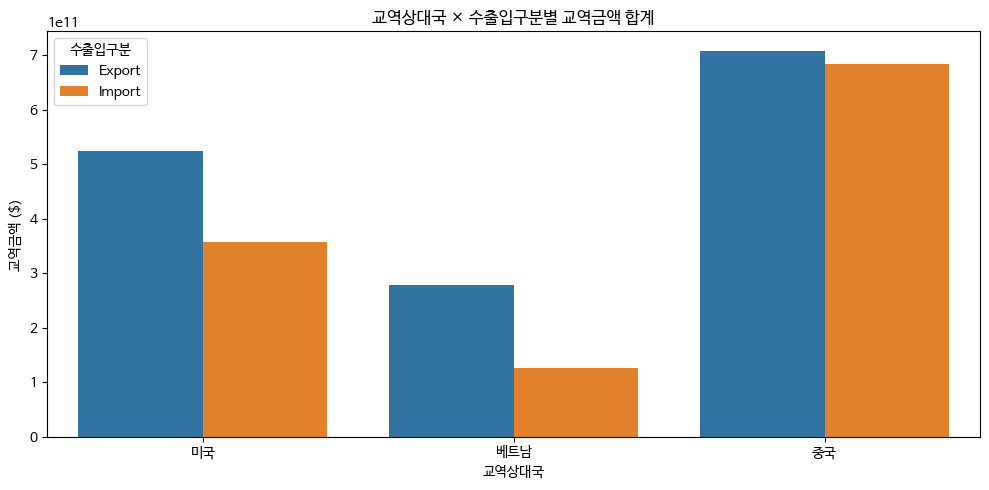

In [ ]:
# 교역상대국 × 수출입구분별 교역금액 합계 (df에서 바로 — estimator='sum')
plt.figure(figsize=(10, 5))

plt.title('교역상대국 × 수출입구분별 교역금액 합계')
plt.ylabel('교역금액 ($)')
plt.xlabel('교역상대국')
plt.tight_layout()
plt.show()

### 11-2. 선그래프 — 연도별 교역금액 추이

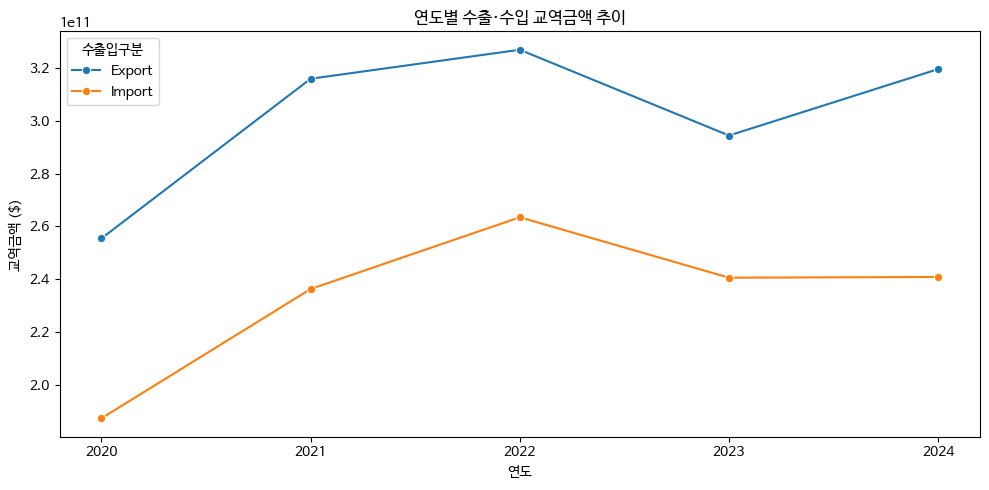

In [ ]:
# 연도별 수출·수입 교역금액 추이 (df에서 바로 — estimator='sum')
plt.figure(figsize=(10, 5))

plt.title('연도별 수출·수입 교역금액 추이')
plt.ylabel('교역금액 ($)')
plt.xticks(df['연도'].unique())
plt.tight_layout()
plt.show()

### 11-3. 가로 막대그래프 — 상위 10개 HS류 교역금액

/tmp/ipykernel_6092/11772446.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hs, x='교역금액($)', y='HS류(2단위)', orient='h', palette='Blues_r')


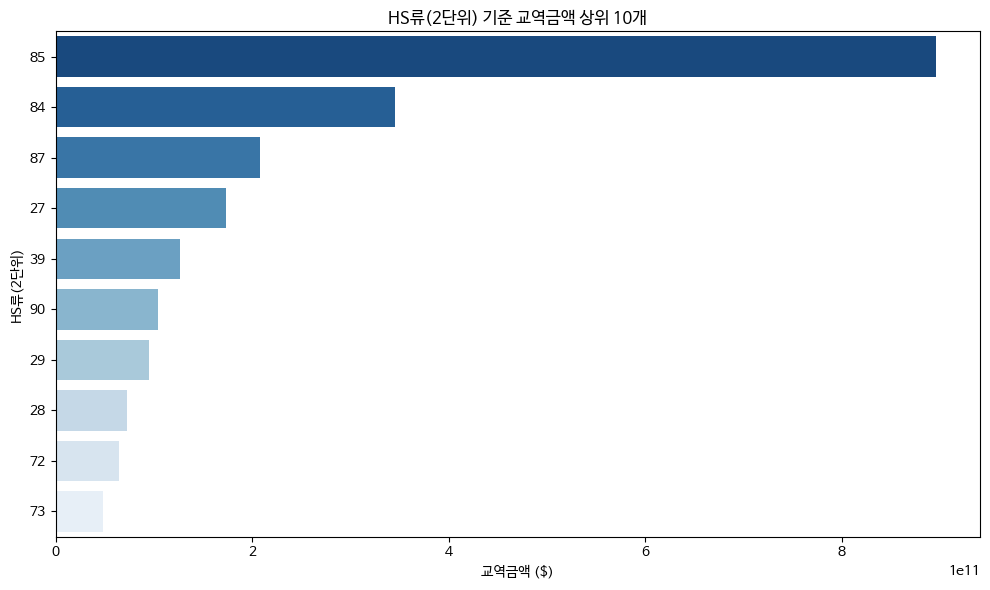

In [ ]:
# 상위 10개 HS류만 집계 (순위 선정에는 groupby가 필요)
top_hs = df.groupby('HS류(2단위)')['교역금액($)'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10, 6))

plt.title('HS류(2단위) 기준 교역금액 상위 10개')
plt.xlabel('교역금액 ($)')
plt.ylabel('HS류(2단위)')
plt.tight_layout()
plt.show()

### 11-4. 히스토그램 — 교역금액 분포

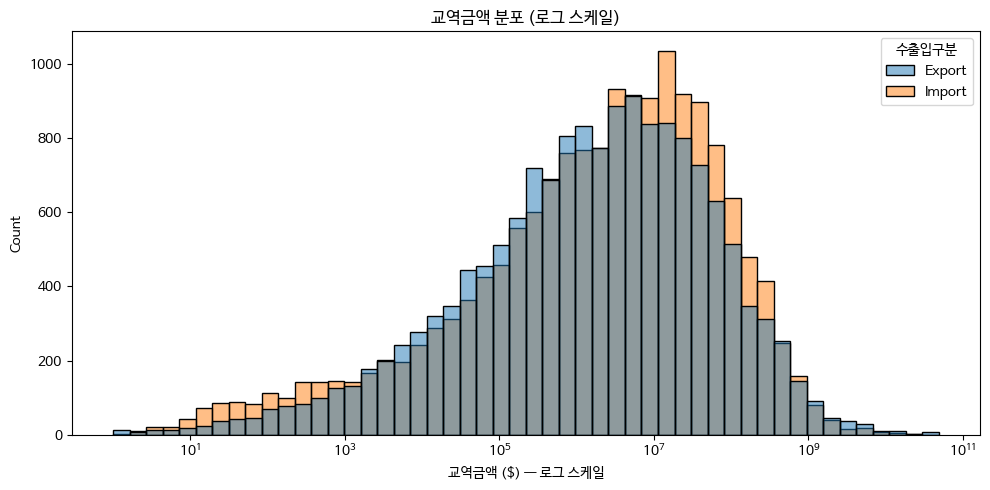

In [ ]:
# 로그 스케일 적용 (교역금액 편차가 커서)
plt.figure(figsize=(10, 5))

plt.title('교역금액 분포 (로그 스케일)')
plt.xlabel('교역금액 ($) — 로그 스케일')
plt.tight_layout()
plt.show()

### 11-5. 박스플롯 — 교역상대국별 교역금액 분포

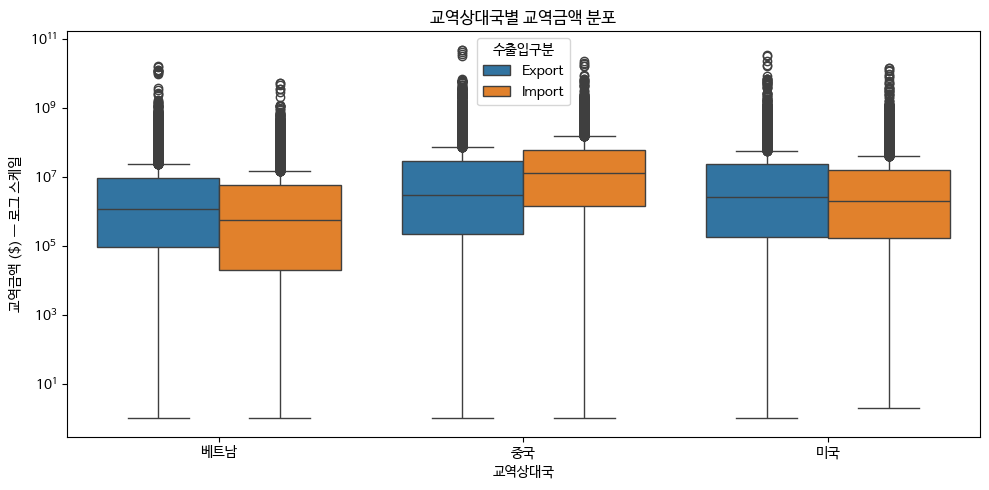

In [ ]:
plt.figure(figsize=(10, 5))

plt.title('교역상대국별 교역금액 분포')
plt.yscale('log')  # y축 로그 스케일
plt.ylabel('교역금액 ($) — 로그 스케일')
plt.xlabel('교역상대국')
plt.tight_layout()
plt.show()

---
## 12. 종합 실습 🎯

지금까지 배운 함수들을 활용해 아래 문제를 풀어보세요.

### 종합 문제 1
**수출(Export)** 데이터만 필터링한 뒤,
`연도`, `교역상대국`, `HS코드`, `교역금액($)` 컬럼만 선택하고
교역금액 내림차순으로 정렬해 **상위 10건**을 출력하세요.

,연도,교역상대국,HS코드,교역금액($)
25889,2024,China,8542,42264473510
28557,2024,USA,8703,35247878595
25840,2024,Viet Nam,8542,16596046564
28465,2024,Viet Nam,8524,10870807353
26568,2024,USA,8473,8221013905
27071,2024,China,8529,7106109546
26583,2024,USA,8708,7070705834
28624,2024,China,2902,5911000691
28390,2024,USA,8523,5444406127
28686,2024,USA,2710,5142924176


### 종합 문제 2
**교역상대국별** 교역금액 합계를 구하고,  
결과를 내림차순으로 정렬해서 출력하세요.  
*(힌트: `groupby` + `sum` + `sort_values`)*

,교역금액($)
교역상대국,
China,1393643016747
USA,883275696772
Viet Nam,403649053654


### 종합 문제 3
품목명에 **'steel'** 또는 **'iron'** 이 포함된 품목만 추출하고,  
**수출입구분별 거래 건수**를 확인하세요.  
*(힌트: `str.contains` + `value_counts`)*

In [ ]:
result =
result['수출입구분'].value_counts()

,count
수출입구분,
Import,895
Export,871


---
## 📌 주요 함수 요약표

| 기능 | 함수 | 예시 |
|:---|:---|:---|
| 파일 읽기 | `pd.read_excel()` / `pd.read_csv()` | `pd.read_excel('data.xlsx')` |
| 크기 확인 | `.shape` | `df.shape` |
| 컬럼 목록 | `.columns` | `df.columns` |
| 기술통계 | `.describe()` | `df.describe()` |
| 앞/뒤 보기 | `.head()` / `.tail()` | `df.head(10)` |
| 고유값 | `.unique()` / `.nunique()` | `df['국가'].unique()` |
| 컬럼 선택 | `df['컬럼']` / `df[['A','B']]` | `df[['연도','교역금액($)']]` |
| 정렬 | `.sort_values()` | `df.sort_values('금액', ascending=False)` |
| 빈도 집계 | `.value_counts()` | `df['국가'].value_counts()` |
| 단일 조건 필터 | 불리언 인덱싱 | `df[df['연도'] == 2024]` |
| 문자열 검색 | `.str.contains()` | `df['품목명'].str.contains('motor')` |
| 결측치 확인 | `.isna().sum()` | `df.isna().sum()` |
| 결측치 채우기 | `.fillna()` | `df['col'].fillna(0)` |
| 결측치 제거 | `.dropna()` | `df.dropna(subset=['col'])` |
| 새 컬럼 생성 | 직접 할당 | `df['새컬럼'] = df['a'] / df['b']` |
| 문자열 처리 | `.str` 접근자 | `df['코드'].astype(str).str[:2]` |
| 그룹 집계 | `.groupby().agg()` | `df.groupby('국가')['금액'].sum()` |
| 중복 확인 | `.duplicated()` | `df.duplicated().sum()` |
| 중복 제거 | `.drop_duplicates()` | `df.drop_duplicates(subset=['키'])` |
| 파일 저장 | `.to_excel()` / `.to_csv()` | `df.to_excel('결과.xlsx', index=False)` |